# Teoria da Decisão - ENTREGA #3: Tomada de Decisão Multicritério

Este notebook implementa métodos de auxílio à tomada de decisão (AHP e TOPSIS) para escolher a melhor solução da fronteira de Pareto obtida na Entrega 2.

## Requisitos atendidos:
- **(a)** Dois métodos de decisão: AHP e TOPSIS
- **(b)** Comparação dos métodos com correlação de Spearman
- **(c)** Quatro atributos conflitantes: Tempo, Distância, Alta Velocidade, Balanceamento
- **(d)** Métodos apropriadamente definidos e apresentados
- **(e)** Critério adicional para incomparabilidade: Índice de Equilíbrio
- **(f)** Gráficos da fronteira com solução escolhida
- **(g)** Gráficos das características da solução final

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from math import pi
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Diretórios
BASE_DIR = Path('.').resolve()
OUTPUT_DIR = BASE_DIR / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

## 1. Carregamento dos Dados da Fronteira Unificada

Carregamos a fronteira unificada obtida a partir da união das fronteiras da Entrega 2 (métodos Soma Ponderada e ε-restrito).

In [ ]:
print("=" * 60)
print("CARREGAMENTO DOS DADOS")
print("=" * 60)

# Carregar fronteira unificada
df_fronteira = pd.read_csv(OUTPUT_DIR / 'fronteira_unificada.csv')

print(f"\nTotal de soluções carregadas: {len(df_fronteira)}")
print(f"  - Epsilon-restrito: {len(df_fronteira[df_fronteira['metodo'] == 'epsilon-restrito'])}")
print(f"  - Soma ponderada: {len(df_fronteira[df_fronteira['metodo'] == 'soma-ponderada'])}")

print("\nAtributos disponíveis (TSP com 250 cidades):")
print("  - Tempo (horas): objetivo original - MINIMIZAR")
print("  - Distância (km): objetivo original - MINIMIZAR")
print("  - Velocidade (trechos acima de vel. máxima): MINIMIZAR (segurança)")
print("  - Balanceamento (desvio padrão das distâncias): MINIMIZAR (regularidade)")

print("\nEstatísticas dos atributos:")
df_fronteira[['tempo', 'distancia', 'velocidade', 'balanceamento']].describe()

## 2. Filtragem das Soluções Não-Dominadas

Aplicamos o conceito de dominância de Pareto para filtrar apenas as soluções não-dominadas, e selecionamos até 20 soluções bem distribuídas ao longo da fronteira.

In [68]:
criterios_minimizacao = ['tempo', 'distancia', 'velocidade', 'balanceamento']


def eh_dominada(idx, df, criterios):
    """Verifica se a solução no índice idx é dominada por alguma outra."""
    solucao = df.loc[idx]
    for outro_idx in df.index:
        if outro_idx == idx:
            continue
        outra = df.loc[outro_idx]

        melhor_em_todos = True
        melhor_em_algum = False

        for crit in criterios:
            if outra[crit] < solucao[crit]:
                melhor_em_algum = True
            elif outra[crit] > solucao[crit]:
                melhor_em_todos = False
                break

        if melhor_em_todos and melhor_em_algum:
            return True
    return False


def filtrar_nao_dominadas(df, criterios):
    """Retorna apenas as soluções não-dominadas."""
    indices_nao_dominadas = []
    for idx in df.index:
        if not eh_dominada(idx, df, criterios):
            indices_nao_dominadas.append(idx)
    return df.loc[indices_nao_dominadas].reset_index(drop=True)


def selecionar_bem_distribuidas(df, criterios, num_solucoes=20):
    """Seleciona soluções bem distribuídas ao longo da fronteira."""
    if len(df) <= num_solucoes:
        return df

    X = df[criterios].values
    X_norm = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0) + 1e-10)

    selecionadas = [0]

    for _ in range(num_solucoes - 1):
        melhor_idx = -1
        maior_dist_min = -1

        for i in range(len(df)):
            if i in selecionadas:
                continue

            dist_min = min(np.linalg.norm(X_norm[i] - X_norm[j]) for j in selecionadas)

            if dist_min > maior_dist_min:
                maior_dist_min = dist_min
                melhor_idx = i

        if melhor_idx >= 0:
            selecionadas.append(melhor_idx)

    return df.iloc[selecionadas].reset_index(drop=True)


# Filtrar e selecionar
df_nao_dominadas = filtrar_nao_dominadas(df_fronteira, criterios_minimizacao)
print(f"\nSoluções não-dominadas: {len(df_nao_dominadas)} de {len(df_fronteira)}")

df_analise = selecionar_bem_distribuidas(df_nao_dominadas, criterios_minimizacao, num_solucoes=20)
print(f"Soluções selecionadas para análise: {len(df_analise)}")

print("\nSoluções selecionadas:")
df_analise[['id', 'metodo', 'tempo', 'distancia', 'velocidade', 'balanceamento']]


Soluções não-dominadas: 25 de 43
Soluções selecionadas para análise: 20

Soluções selecionadas:


,id,metodo,tempo,distancia,velocidade,balanceamento
0,pe_1927554880,epsilon-restrito,27.5,1725.6,40,12.32
1,pe_3998479150,epsilon-restrito,30.5,1437.5,106,22.36
2,pw_3049399490,soma-ponderada,27.5,1440.7,67,23.86
3,pw_2670724850,soma-ponderada,26.7,1550.4,73,14.30
4,pw_3616227340,soma-ponderada,29.2,1498.3,84,17.53
5,pe_3118919890,epsilon-restrito,28.7,1410.6,106,23.90
6,pe_470784595,epsilon-restrito,28.8,1802.9,31,9.23
7,pw_4114543940,soma-ponderada,26.8,1600.1,33,15.45
8,pw_422791300,soma-ponderada,27.5,1547.9,53,19.26
9,pw_628818625,soma-ponderada,26.7,1775.7,21,9.41


## 3. Método AHP (Analytic Hierarchy Process)

### Descrição Teórica

O **AHP** é um método de tomada de decisão multicritério desenvolvido por Thomas Saaty que permite:
- Estruturar problemas complexos em hierarquias
- Comparar critérios par-a-par usando a escala de Saaty (1-9)
- Calcular pesos através do autovetor principal
- Verificar consistência através da Razão de Consistência (CR < 0.1)

### Escala de Saaty
| Valor | Significado |
|-------|-------------|
| 1 | Igual importância |
| 2 | Levemente mais importante |
| 3 | Moderadamente mais importante |
| 4-5 | Fortemente mais importante |
| 6-7 | Muito mais importante |
| 8-9 | Extremamente mais importante |

In [69]:
def calcular_pesos_ahp(matriz_comparacao):
    """
    Calcula os pesos dos critérios usando o método AHP.
    """
    autovalores, autovetores = np.linalg.eig(matriz_comparacao)
    idx_max = np.argmax(np.real(autovalores))
    autovetor_principal = np.real(autovetores[:, idx_max])
    pesos = autovetor_principal / autovetor_principal.sum()

    lambda_max = np.real(autovalores[idx_max])
    n = len(matriz_comparacao)
    CI = (lambda_max - n) / (n - 1)

    RI_dict = {1: 0, 2: 0, 3: 0.58, 4: 0.90, 5: 1.12, 6: 1.24, 7: 1.32, 8: 1.41, 9: 1.45}
    RI = RI_dict.get(n, 1.45)
    CR = CI / RI if RI > 0 else 0

    return pesos, CR, lambda_max


# Matriz de comparação par-a-par dos critérios
# Hierarquia definida por pesos: Tempo=7, Distância=5, Velocidade=3, Balanceamento=1
# As comparações são razões entre os pesos, garantindo consistência perfeita (CR ≈ 0)
matriz_comparacao_ahp = np.array([
    #    Tempo    Dist     Veloc    Balanc
    [1,      7/5,     7/3,     7],      # Tempo
    [5/7,    1,       5/3,     5],      # Distância
    [3/7,    3/5,     1,       3],      # Velocidade
    [1/7,    1/5,     1/3,     1],      # Balanceamento
])

pesos_ahp, CR, lambda_max = calcular_pesos_ahp(matriz_comparacao_ahp)

print("=" * 60)
print("MÉTODO AHP - Analytic Hierarchy Process")
print("=" * 60)

print("\nMatriz de Comparação Par-a-Par (Escala Saaty):")
criterios_nomes = ['Tempo', 'Distância', 'Velocidade', 'Balanc.']
df_matriz = pd.DataFrame(matriz_comparacao_ahp, index=criterios_nomes, columns=criterios_nomes)
print(df_matriz.round(3))

print("\nPesos calculados pelo AHP:")
for nome, peso in zip(criterios_nomes, pesos_ahp):
    print(f"  {nome}: {peso:.4f} ({peso*100:.1f}%)")

print(f"\nÍndices de Consistência:")
print(f"  Lambda máximo: {lambda_max:.4f}")
print(f"  Razão de Consistência (CR): {CR:.4f}")
if CR < 0.1:
    print("  ✓ Matriz é consistente (CR < 0.1)")
else:
    print("  ⚠ Matriz pode ser inconsistente (CR >= 0.1)")

MÉTODO AHP - Analytic Hierarchy Process

Matriz de Comparação Par-a-Par (Escala Saaty):
            Tempo  Distância  Velocidade  Balanc.
Tempo       1.000        1.4       2.333      7.0
Distância   0.714        1.0       1.667      5.0
Velocidade  0.429        0.6       1.000      3.0
Balanc.     0.143        0.2       0.333      1.0

Pesos calculados pelo AHP:
  Tempo: 0.4375 (43.7%)
  Distância: 0.3125 (31.3%)
  Velocidade: 0.1875 (18.7%)
  Balanc.: 0.0625 (6.2%)

Índices de Consistência:
  Lambda máximo: 4.0000
  Razão de Consistência (CR): 0.0000
  ✓ Matriz é consistente (CR < 0.1)


In [70]:
def aplicar_ahp_ranking(df, pesos, criterios):
    """Aplica ranking baseado nos pesos do AHP."""
    matriz = df[criterios].values

    matriz_norm = np.zeros_like(matriz, dtype=float)
    for j in range(len(criterios)):
        col_min = matriz[:, j].min()
        col_max = matriz[:, j].max()
        if col_max > col_min:
            matriz_norm[:, j] = (matriz[:, j] - col_min) / (col_max - col_min)
        else:
            matriz_norm[:, j] = 0

    scores = (matriz_norm * pesos).sum(axis=1)
    return scores


scores_ahp = aplicar_ahp_ranking(df_analise, pesos_ahp, criterios_minimizacao)
df_analise['Score_AHP'] = scores_ahp
df_analise['Rank_AHP'] = df_analise['Score_AHP'].rank(ascending=True)

print("\nTop 10 soluções pelo AHP (menor score = melhor):")
df_analise.nsmallest(10, 'Score_AHP')[['id', 'tempo', 'distancia', 'Score_AHP', 'Rank_AHP']]


Top 10 soluções pelo AHP (menor score = melhor):


,id,tempo,distancia,Score_AHP,Rank_AHP
7,pw_4114543940,26.8,1600.1,0.222207,1.0
12,pw_2370499670,26.6,1510.7,0.230488,2.0
13,pw_3270801105,26.8,1506.0,0.237782,3.0
3,pw_2670724850,26.7,1550.4,0.255537,4.0
17,pw_414955215,26.9,1668.4,0.271682,5.0
2,pw_3049399490,27.5,1440.7,0.278926,6.0
19,pw_3634258720,27.3,1516.6,0.295805,7.0
9,pw_628818625,26.7,1775.7,0.302706,8.0
8,pw_422791300,27.5,1547.9,0.316928,9.0
11,pe_589439845,27.9,1451.4,0.379369,10.0


## 4. Método TOPSIS

### Descrição Teórica

O **TOPSIS** (Technique for Order Preference by Similarity to Ideal Solution) seleciona a alternativa:
- Mais próxima da **solução ideal** (melhores valores em todos os critérios)
- Mais distante da **solução anti-ideal** (piores valores em todos os critérios)

### Etapas:
1. Normalização vetorial da matriz de decisão
2. Ponderação pelos pesos (do AHP)
3. Identificação das soluções ideal e anti-ideal
4. Cálculo das distâncias euclidianas
5. Cálculo do coeficiente de proximidade relativa

In [71]:
def topsis(df, pesos, criterios):
    """Aplica o método TOPSIS para ranking de alternativas."""
    matriz = df[criterios].values

    # 1. Normalização vetorial
    soma_quadrados = np.sqrt((matriz ** 2).sum(axis=0))
    matriz_norm = matriz / (soma_quadrados + 1e-10)

    # 2. Ponderação
    matriz_pond = matriz_norm * pesos

    # 3. Soluções ideal e anti-ideal (todos são minimização)
    ideal = matriz_pond.min(axis=0)
    anti_ideal = matriz_pond.max(axis=0)

    # 4. Distâncias euclidianas
    dist_ideal = np.sqrt(((matriz_pond - ideal) ** 2).sum(axis=1))
    dist_anti_ideal = np.sqrt(((matriz_pond - anti_ideal) ** 2).sum(axis=1))

    # 5. Coeficiente de proximidade relativa (maior = melhor)
    scores = dist_anti_ideal / (dist_ideal + dist_anti_ideal + 1e-10)

    return scores


print("=" * 60)
print("MÉTODO TOPSIS")
print("=" * 60)

scores_topsis = topsis(df_analise, pesos_ahp, criterios_minimizacao)
df_analise['Score_TOPSIS'] = scores_topsis
df_analise['Rank_TOPSIS'] = df_analise['Score_TOPSIS'].rank(ascending=False)

print("\nTop 10 soluções pelo TOPSIS (maior score = melhor):")
df_analise.nlargest(10, 'Score_TOPSIS')[['id', 'tempo', 'distancia', 'Score_TOPSIS', 'Rank_TOPSIS']]

MÉTODO TOPSIS

Top 10 soluções pelo TOPSIS (maior score = melhor):


,id,tempo,distancia,Score_TOPSIS,Rank_TOPSIS
17,pw_414955215,26.9,1668.4,0.795548,1.0
7,pw_4114543940,26.8,1600.1,0.795137,2.0
9,pw_628818625,26.7,1775.7,0.763683,3.0
6,pe_470784595,28.8,1802.9,0.696724,4.0
0,pe_1927554880,27.5,1725.6,0.692726,5.0
8,pw_422791300,27.5,1547.9,0.623024,6.0
13,pw_3270801105,26.8,1506.0,0.547655,7.0
19,pw_3634258720,27.3,1516.6,0.530052,8.0
2,pw_3049399490,27.5,1440.7,0.507215,9.0
3,pw_2670724850,26.7,1550.4,0.466791,10.0


## 5. Comparação dos Métodos

In [72]:
print("=" * 60)
print("COMPARAÇÃO ENTRE MÉTODOS AHP E TOPSIS")
print("=" * 60)

# Correlação de Spearman
correlacao, p_value = spearmanr(df_analise['Rank_AHP'], df_analise['Rank_TOPSIS'])

print(f"\nCorrelação de Spearman entre rankings: {correlacao:.4f}")
print(f"P-valor: {p_value:.6f}")

if correlacao > 0.7:
    print("✓ Alta concordância entre os métodos")
elif correlacao > 0.4:
    print("⚠ Concordância moderada entre os métodos")
else:
    print("✗ Baixa concordância entre os métodos")

# Comparar Top 5
top5_ahp = set(df_analise.nsmallest(5, 'Score_AHP').index)
top5_topsis = set(df_analise.nlargest(5, 'Score_TOPSIS').index)
solucoes_comuns = top5_ahp.intersection(top5_topsis)

print(f"\nSoluções no Top 5 de ambos os métodos: {len(solucoes_comuns)}")
if solucoes_comuns:
    print(f"Índices: {sorted(solucoes_comuns)}")

print("\n--- Top 5 AHP (menor score = melhor) ---")
display(df_analise.nsmallest(5, 'Score_AHP')[['id', 'tempo', 'distancia', 'velocidade', 'balanceamento', 'Score_AHP', 'Rank_AHP']])

print("\n--- Top 5 TOPSIS (maior score = melhor) ---")
display(df_analise.nlargest(5, 'Score_TOPSIS')[['id', 'tempo', 'distancia', 'velocidade', 'balanceamento', 'Score_TOPSIS', 'Rank_TOPSIS']])

COMPARAÇÃO ENTRE MÉTODOS AHP E TOPSIS

Correlação de Spearman entre rankings: 0.5173
P-valor: 0.019501
⚠ Concordância moderada entre os métodos

Soluções no Top 5 de ambos os métodos: 2
Índices: [7, 17]

--- Top 5 AHP (menor score = melhor) ---


,id,tempo,distancia,velocidade,balanceamento,Score_AHP,Rank_AHP
7,pw_4114543940,26.8,1600.1,33,15.45,0.222207,1.0
12,pw_2370499670,26.6,1510.7,74,18.65,0.230488,2.0
13,pw_3270801105,26.8,1506.0,62,22.86,0.237782,3.0
3,pw_2670724850,26.7,1550.4,73,14.30,0.255537,4.0
17,pw_414955215,26.9,1668.4,26,15.26,0.271682,5.0



--- Top 5 TOPSIS (maior score = melhor) ---


,id,tempo,distancia,velocidade,balanceamento,Score_TOPSIS,Rank_TOPSIS
17,pw_414955215,26.9,1668.4,26,15.26,0.795548,1.0
7,pw_4114543940,26.8,1600.1,33,15.45,0.795137,2.0
9,pw_628818625,26.7,1775.7,21,9.41,0.763683,3.0
6,pe_470784595,28.8,1802.9,31,9.23,0.696724,4.0
0,pe_1927554880,27.5,1725.6,40,12.32,0.692726,5.0


## 6. Critério Adicional para Desempate/Incomparabilidade

Caso não haja concordância clara entre os métodos, aplicamos um critério adicional: **Índice de Equilíbrio**.

Soluções com melhor equilíbrio têm desempenho mais uniforme em todos os critérios (menor variância normalizada).

In [ ]:
def calcular_equilibrio(row, criterios):
    """Calcula índice de equilíbrio baseado na variância normalizada."""
    valores = [row[crit] for crit in criterios]
    valores_norm = (np.array(valores) - np.min(valores)) / (np.max(valores) - np.min(valores) + 1e-10)
    return np.std(valores_norm)


df_analise['Equilibrio'] = df_analise.apply(lambda row: calcular_equilibrio(row, criterios_minimizacao), axis=1)

# Decisão final
if len(solucoes_comuns) > 0:
    print("\n✓ Concordância encontrada entre métodos!")
    print(f"  Selecionando entre {len(solucoes_comuns)} soluções comuns ao Top 5...")

    candidatas = df_analise.loc[list(solucoes_comuns)]

    score_ahp_norm = 1 - (candidatas['Score_AHP'] - candidatas['Score_AHP'].min()) / \
                        (candidatas['Score_AHP'].max() - candidatas['Score_AHP'].min() + 1e-10)
    score_topsis_norm = (candidatas['Score_TOPSIS'] - candidatas['Score_TOPSIS'].min()) / \
                        (candidatas['Score_TOPSIS'].max() - candidatas['Score_TOPSIS'].min() + 1e-10)

    score_combinado = (score_ahp_norm + score_topsis_norm) / 2
    idx_escolhido = score_combinado.idxmax()

else:
    print("\n⚠ Sem concordância clara entre métodos")
    print("  Aplicando critério adicional: melhor equilíbrio entre Top 10...")

    top10_ahp = set(df_analise.nsmallest(10, 'Score_AHP').index)
    top10_topsis = set(df_analise.nlargest(10, 'Score_TOPSIS').index)
    candidatas_idx = top10_ahp.intersection(top10_topsis)

    if len(candidatas_idx) > 0:
        candidatas = df_analise.loc[list(candidatas_idx)]
        idx_escolhido = candidatas['Equilibrio'].idxmin()
    else:
        idx_escolhido = df_analise['Equilibrio'].idxmin()

solucao_final = df_analise.loc[idx_escolhido]

print("\n" + "=" * 60)
print("SOLUÇÃO FINAL ESCOLHIDA")
print("=" * 60)
print(f"\nID: {solucao_final['id']}")
print(f"Método de origem: {solucao_final['metodo']}")
print(f"\nAtributos:")
print(f"  Tempo Total: {solucao_final['tempo']:.2f} horas")
print(f"  Distância Total: {solucao_final['distancia']:.2f} km")
print(f"  Trechos acima vel. máxima: {solucao_final['velocidade']:.0f} (de 250)")
print(f"  Balanceamento (desvio padrão): {solucao_final['balanceamento']:.2f}")
print(f"\nScores:")
print(f"  Score AHP: {solucao_final['Score_AHP']:.4f} (Rank: {solucao_final['Rank_AHP']:.0f})")
print(f"  Score TOPSIS: {solucao_final['Score_TOPSIS']:.4f} (Rank: {solucao_final['Rank_TOPSIS']:.0f})")
print(f"  Índice de Equilíbrio: {solucao_final['Equilibrio']:.4f}")

## 7. Visualizações

### 7.1 Fronteira de Pareto com Solução Escolhida (Requisito f)

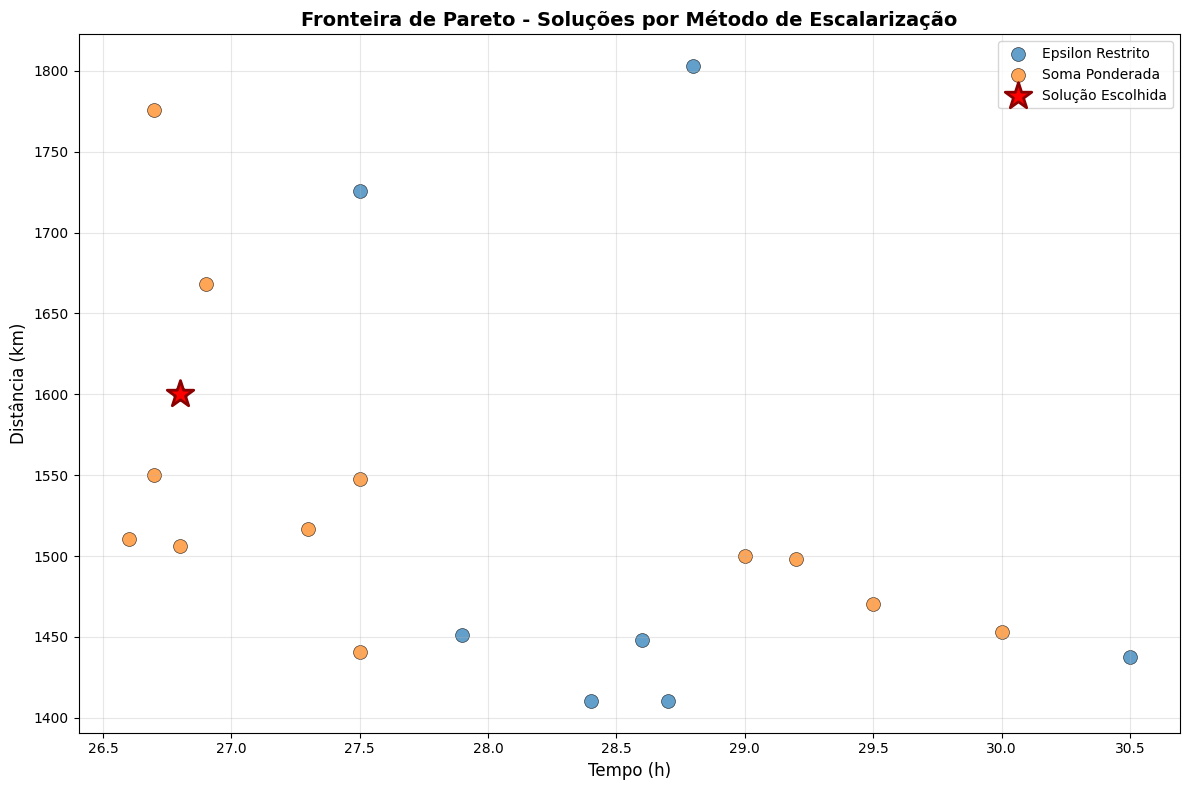

In [74]:
# Figura 1: Fronteira por método de origem (estilo TD_ENTREGA2)
plt.figure(figsize=(12, 8))
cores = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]

metodos = df_analise['metodo'].unique()
for idx, metodo in enumerate(metodos):
    subset = df_analise[df_analise['metodo'] == metodo]
    plt.scatter(
        subset['tempo'],
        subset['distancia'],
        color=cores[idx % len(cores)],
        alpha=0.7,
        s=100,
        label=metodo.replace('-', ' ').title(),
        edgecolors='black',
        linewidth=0.5,
    )

plt.scatter(
    solucao_final['tempo'],
    solucao_final['distancia'],
    color='red',
    s=400,
    marker='*',
    edgecolors='darkred',
    linewidth=2,
    label='Solução Escolhida',
    zorder=10,
)

plt.xlabel("Tempo (h)", fontsize=12)
plt.ylabel("Distância (km)", fontsize=12)
plt.title("Fronteira de Pareto - Soluções por Método de Escalarização", fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fronteira_metodos.png", dpi=150)
plt.show()

In [ ]:
# Figura 2: Fronteira 2D com solução escolhida
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Tempo vs Distância
ax1 = axes[0]
ax1.scatter(df_analise['distancia'], df_analise['tempo'], alpha=0.6, s=80, c='lightblue', edgecolors='black', linewidth=0.5, label='Soluções da Fronteira')
ax1.scatter(solucao_final['distancia'], solucao_final['tempo'], color='red', s=300, marker='*', edgecolors='darkred', linewidth=2, label='Solução Escolhida', zorder=5)
ax1.set_xlabel('Distância Total (km)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Tempo Total (horas)', fontsize=12, fontweight='bold')
ax1.set_title('Fronteira de Pareto - Distância vs Tempo', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Velocidade vs Balanceamento
ax2 = axes[1]
ax2.scatter(df_analise['velocidade'], df_analise['balanceamento'], alpha=0.6, s=80, c='lightgreen', edgecolors='black', linewidth=0.5, label='Soluções da Fronteira')
ax2.scatter(solucao_final['velocidade'], solucao_final['balanceamento'], color='red', s=300, marker='*', edgecolors='darkred', linewidth=2, label='Solução Escolhida', zorder=5)
ax2.set_xlabel('Trechos acima vel. máxima', fontsize=12, fontweight='bold')
ax2.set_ylabel('Balanceamento (Desvio Padrão)', fontsize=12, fontweight='bold')
ax2.set_title('Fronteira de Pareto - Velocidade vs Balanceamento', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figura_fronteira_solucao.png", dpi=150, bbox_inches='tight')
plt.show()

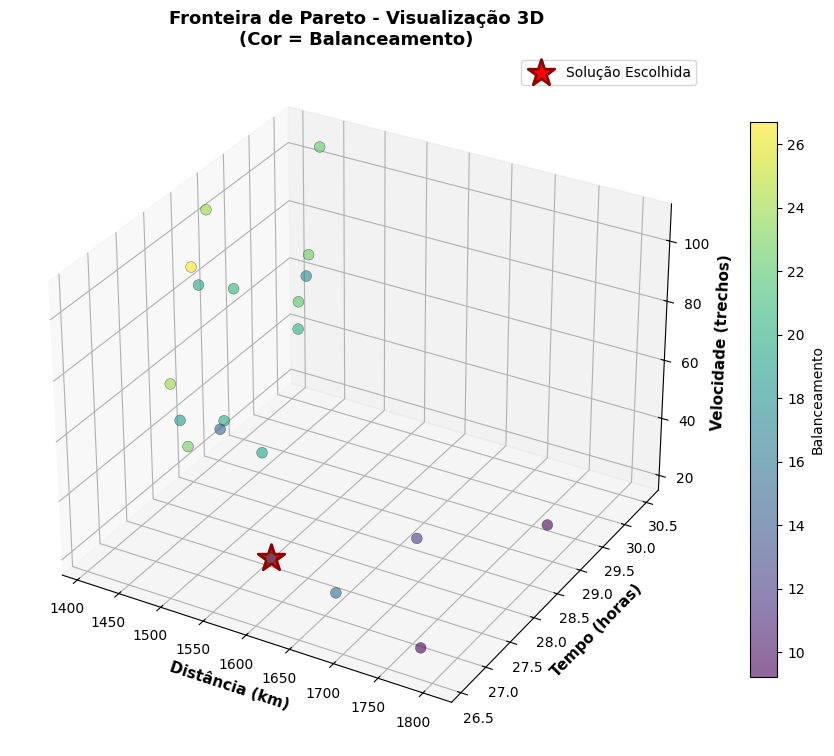

In [76]:
# Figura 3: Visualização 3D
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_analise['distancia'],
    df_analise['tempo'],
    df_analise['velocidade'],
    alpha=0.6,
    s=60,
    c=df_analise['balanceamento'],
    cmap='viridis',
    edgecolors='black',
    linewidth=0.3,
)

ax.scatter(
    solucao_final['distancia'],
    solucao_final['tempo'],
    solucao_final['velocidade'],
    color='red',
    s=400,
    marker='*',
    edgecolors='darkred',
    linewidth=2,
    label='Solução Escolhida',
)

ax.set_xlabel('Distância (km)', fontsize=11, fontweight='bold')
ax.set_ylabel('Tempo (horas)', fontsize=11, fontweight='bold')
ax.set_zlabel('Velocidade (trechos)', fontsize=11, fontweight='bold')
ax.set_title('Fronteira de Pareto - Visualização 3D\n(Cor = Balanceamento)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

plt.colorbar(scatter, ax=ax, label='Balanceamento', shrink=0.8)
plt.savefig(OUTPUT_DIR / "figura_fronteira_3d.png", dpi=150, bbox_inches='tight')
plt.show()

### 7.2 Características da Solução Final (Requisito g)

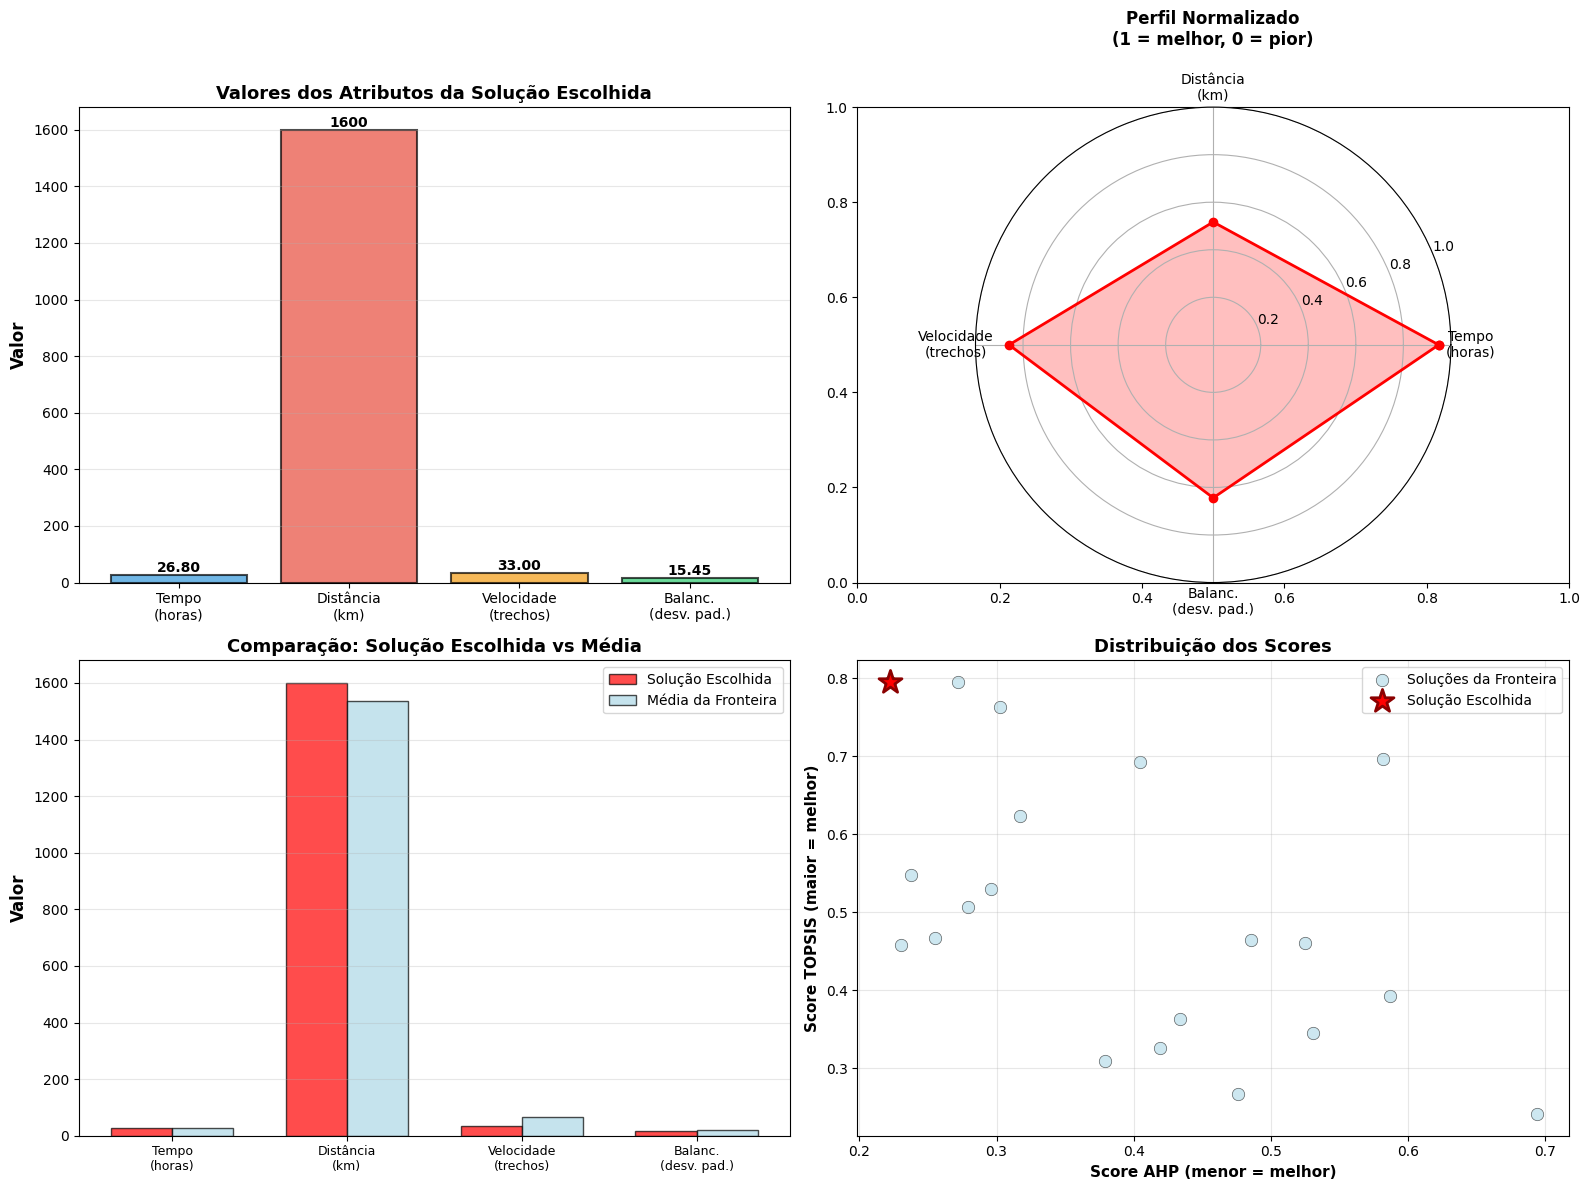

In [77]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Valores dos atributos
atributos_nomes = ['Tempo\n(horas)', 'Distância\n(km)', 'Velocidade\n(trechos)', 'Balanc.\n(desv. pad.)']
valores = [
    solucao_final['tempo'],
    solucao_final['distancia'],
    solucao_final['velocidade'],
    solucao_final['balanceamento'],
]

# Gráfico 1: Barras
ax1 = axes[0, 0]
cores = ['#3498db', '#e74c3c', '#f39c12', '#2ecc71']
barras = ax1.bar(atributos_nomes, valores, color=cores, alpha=0.7, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Valor', fontsize=12, fontweight='bold')
ax1.set_title('Valores dos Atributos da Solução Escolhida', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

for barra, valor in zip(barras, valores):
    altura = barra.get_height()
    ax1.text(barra.get_x() + barra.get_width() / 2.0, altura, f'{valor:.2f}' if valor < 100 else f'{valor:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Gráfico 2: Radar
ax2 = plt.subplot(2, 2, 2, projection='polar')

valores_max = [df_analise[c].max() for c in criterios_minimizacao]
valores_min = [df_analise[c].min() for c in criterios_minimizacao]

valores_norm = []
for valor, vmax, vmin in zip(valores, valores_max, valores_min):
    if vmax > vmin:
        norm = 1 - (valor - vmin) / (vmax - vmin)
    else:
        norm = 0.5
    valores_norm.append(norm)

valores_norm += valores_norm[:1]
angulos = [n / float(len(atributos_nomes)) * 2 * pi for n in range(len(atributos_nomes))]
angulos += angulos[:1]

ax2.plot(angulos, valores_norm, 'o-', linewidth=2, color='red', label='Solução Escolhida')
ax2.fill(angulos, valores_norm, alpha=0.25, color='red')
ax2.set_xticks(angulos[:-1])
ax2.set_xticklabels(atributos_nomes, fontsize=10)
ax2.set_ylim(0, 1)
ax2.set_title('Perfil Normalizado\n(1 = melhor, 0 = pior)', fontsize=12, fontweight='bold', pad=20)
ax2.grid(True)

# Gráfico 3: Comparação com média
ax3 = axes[1, 0]
valores_media = [
    df_analise['tempo'].mean(),
    df_analise['distancia'].mean(),
    df_analise['velocidade'].mean(),
    df_analise['balanceamento'].mean(),
]

x = np.arange(len(atributos_nomes))
width = 0.35

ax3.bar(x - width/2, valores, width, label='Solução Escolhida', color='red', alpha=0.7, edgecolor='black')
ax3.bar(x + width/2, valores_media, width, label='Média da Fronteira', color='lightblue', alpha=0.7, edgecolor='black')

ax3.set_ylabel('Valor', fontsize=12, fontweight='bold')
ax3.set_title('Comparação: Solução Escolhida vs Média', fontsize=13, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(atributos_nomes, fontsize=9)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')

# Gráfico 4: Scores
ax4 = axes[1, 1]
ax4.scatter(df_analise['Score_AHP'], df_analise['Score_TOPSIS'], alpha=0.6, s=80, c='lightblue', edgecolors='black', linewidth=0.5, label='Soluções da Fronteira')
ax4.scatter(solucao_final['Score_AHP'], solucao_final['Score_TOPSIS'], color='red', s=300, marker='*', edgecolors='darkred', linewidth=2, label='Solução Escolhida', zorder=5)
ax4.set_xlabel('Score AHP (menor = melhor)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Score TOPSIS (maior = melhor)', fontsize=11, fontweight='bold')
ax4.set_title('Distribuição dos Scores', fontsize=13, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "figura_solucao_final.png", dpi=150, bbox_inches='tight')
plt.show()

## 8. Resumo Final

In [78]:
print("\n" + "=" * 80)
print("RESUMO FINAL DA ANÁLISE")
print("=" * 80)

print(f"\n{'Atributo':<30} {'Solução':<15} {'Média':<15} {'Comparação':<20}")
print("-" * 80)

atributos_print = ['Tempo (horas)', 'Distância (km)', 'Alta Velocidade', 'Balanceamento']
for attr, valor, media in zip(atributos_print, valores, valores_media):
    diff = valor - media
    diff_pct = (diff / media * 100) if media > 0 else 0
    comparacao = f"{diff:+.2f} ({diff_pct:+.1f}%)"
    print(f"{attr:<30} {valor:<15.2f} {media:<15.2f} {comparacao:<20}")

print("=" * 80)

print("\nFiguras salvas em outputs/:")
print("  - fronteira_metodos.png")
print("  - figura_fronteira_solucao.png")
print("  - figura_fronteira_3d.png")
print("  - figura_solucao_final.png")

# Salvar resultados
df_analise.to_csv(OUTPUT_DIR / 'resultados_decisao.csv', index=False)
print("\nResultados salvos em: outputs/resultados_decisao.csv")


RESUMO FINAL DA ANÁLISE

Atributo                       Solução         Média           Comparação          
--------------------------------------------------------------------------------
Tempo (horas)                  26.80           28.04           -1.24 (-4.4%)       
Distância (km)                 1600.10         1536.25         +63.85 (+4.2%)      
Alta Velocidade                33.00           66.25           -33.25 (-50.2%)     
Balanceamento                  15.45           18.80           -3.35 (-17.8%)      

Figuras salvas em outputs/:
  - fronteira_metodos.png
  - figura_fronteira_solucao.png
  - figura_fronteira_3d.png
  - figura_solucao_final.png

Resultados salvos em: outputs/resultados_decisao.csv
